# 수출 모멘텀 vs 주가 수익률: 리드-래그(선행-동행) 분석

**목적**: 특정 HS 코드(들)의 수출 YoY 성장률 및 그 가속도(모멘텀 변화)가,
향후 특정 종목의 주가 수익률(1개월/3개월/6개월)에 선행하는 관계가 있는지 확인합니다.

- 설명변수(X): HS 코드 조합의 월별 수출 YoY 성장률(%), YoY 가속도(%p)
- 종속변수(Y): 지정 티커의 향후 1/3/6개월 누적 주가 수익률(%)
- 분석 대상 기간에 대해서는 **실적(actual) 수출 데이터만 사용**합니다 (예측치는 아직 실현되지 않은 값이라
  향후 주가와 사후적으로 비교할 수 없으므로 backtest에서 제외합니다).
- ⚠️ 상관관계/회귀 결과는 **인과관계를 증명하지 않습니다**. 표본 수가 적을 수 있고,
  여러 조합을 동시에 검정하면 우연히 유의해 보이는 결과가 나올 수 있으니 참고용으로만 활용하세요.


## ① 환경 설정 및 DB 연결

In [1]:
# -*- coding: utf-8 -*-
from __future__ import annotations

import os
import sys
import socket
import time
import subprocess
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import pymysql
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# DATA 모듈 자동 탐색 (작업 디렉토리가 달라도 동작하도록)
# ------------------------------------------------------------
def _find_project_root(module_name: str = "DATA", max_up: int = 6):
    here = Path.cwd()
    for base in [here] + list(here.parents)[:max_up]:
        if (base / module_name).is_dir():
            return base
    return None

try:
    from DATA.stock_invest_function import *
except ModuleNotFoundError:
    _root = _find_project_root("DATA")
    if _root is None:
        raise ModuleNotFoundError("DATA 패키지를 찾을 수 없습니다. 프로젝트 루트에서 실행해 주세요.")
    sys.path.insert(0, str(_root))
    from DATA.stock_invest_function import *

# ------------------------------------------------------------
# 한글 폰트 자동 선택
# ------------------------------------------------------------
def _pick_korean_font() -> str:
    system = platform.system()
    candidates = {
        "Windows": ["Malgun Gothic", "NanumGothic"],
        "Darwin":  ["AppleGothic", "NanumGothic"],
        "Linux":   ["NanumGothic", "Noto Sans CJK KR", "DejaVu Sans"],
    }.get(system, ["DejaVu Sans"])
    available = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            return name
    return "DejaVu Sans"

matplotlib.rc('font', family=_pick_korean_font())
plt.rcParams['axes.unicode_minus'] = False

# ------------------------------------------------------------
# 어디서나(집/외부) 접속 가능한 DB host 자동 탐색
#   - 내부 IP(192.168.0.230)를 먼저 시도, 안 되면 외부 DDNS로 자동 전환
# ------------------------------------------------------------
DB_HOST_LAN  = "192.168.0.230"
DB_HOST_DDNS = "hystox74.synology.me"
DB_PORT = 3307


def _candidate_hosts() -> list:
    cands = [os.environ.get("DB_HOST_OVERRIDE"), DB_HOST_LAN, DB_HOST_DDNS]
    seen, out = set(), []
    for h in cands:
        if h and h not in seen:
            seen.add(h)
            out.append(h)
    return out


def _is_reachable(host: str, port: int, timeout: float = 1.5) -> bool:
    try:
        with socket.create_connection((host, port), timeout=timeout):
            return True
    except OSError:
        return False


def resolve_db_host(port: int = DB_PORT, timeout: float = 1.5) -> str:
    print("[DB 접속] 접속 가능한 host 탐색 중...")
    for host in _candidate_hosts():
        t0 = time.time()
        ok = _is_reachable(host, port, timeout)
        print(f"   - {host}:{port}  {'연결됨' if ok else '실패'}  ({time.time() - t0:.1f}s)")
        if ok:
            return host
    raise ConnectionError("192.168.0.230(내부), hystox74.synology.me(외부) 모두 연결할 수 없습니다.")


db_info = {
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'host': resolve_db_host(),
    'port': DB_PORT,
    'database': 'investar',
}


def make_engine(db_info: dict):
    url = (
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
        f"@{db_info['host']}:{int(db_info['port'])}/{db_info['database']}?charset=utf8mb4"
    )
    return create_engine(url, pool_pre_ping=True, pool_recycle=1800,
                          connect_args={"connect_timeout": 10, "read_timeout": 60, "write_timeout": 60})


engine = make_engine(db_info)
TABLE_NAME = "korea_monthly_trade_forecast_v2"
print("DB 연결 완료:", db_info['host'])


# ------------------------------------------------------------
# 필요 패키지 자동 설치 헬퍼 (주가 라이브러리용)
# ------------------------------------------------------------
def _ensure_package(import_name: str, pip_name: str | None = None):
    pip_name = pip_name or import_name
    try:
        return __import__(import_name)
    except ImportError:
        print(f"[설치] '{pip_name}' 패키지가 없어 설치를 시도합니다...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name, "--quiet"])
        return __import__(import_name)


# ------------------------------------------------------------
# pivot_dataframe: 원본 노트북에서 로컬로 정의되어 있던 헬퍼 함수
#   (DATA.stock_invest_function 모듈이 아니라 노트북 셀에 직접 정의돼 있었으므로 여기 옮겨옵니다)
# ------------------------------------------------------------
def pivot_dataframe(df, index_col='date', column_col='root_hs_code',
                     indicator_col='indicator', value_col='value', indicator_value='expDlr'):
    """
    주어진 DataFrame에서 특정 indicator 값에 해당하는 데이터를 필터링하여 pivot table을 생성합니다.
    """
    filtered_df = df[df[indicator_col] == indicator_value].copy()
    pivot_df = filtered_df.pivot(index=index_col, columns=column_col, values=value_col)
    return pivot_df


[DB 접속] 접속 가능한 host 탐색 중...
   - 192.168.0.230:3307  연결됨  (0.0s)
DB 연결 완료: 192.168.0.230


## ② 사용자 입력 — 여기만 수정하면 됩니다

In [2]:
# ============================================================
# ★ 사용자 입력 ★
# ============================================================
HSCODE_LIST = ["854232"]          # 분석할 HS 코드 (여러 개면 합산 — 예: ["854232", "852351"])
INDICATOR   = "ensemble_expDlr"   # (참고용, 이 노트북에서는 실적만 사용하므로 직접 쓰이진 않음)

TICKER   = "000660"    # 분석할 종목 코드
MARKET   = "KR"         # "KR" (한국, FinanceDataReader) 또는 "US" (미국, yfinance)
TICKER_NAME = "SK하이닉스"  # 표시용 이름 (선택)

YEARS_STOCK = 10        # 주가 수집 기간(최근 n년)

HORIZONS = {1: "1개월(월간)", 3: "3개월(분기)", 6: "6개월(반기)"}   # 향후 수익률 측정 기간(개월)
SCATTER_XVAR = "export_yoy_accel(%p)"   # 산점도 대표 X변수 (또는 "export_yoy(%)")
SCATTER_H = 3                            # 산점도 대표 예측기간(개월)
# ============================================================

print(f"HS 코드: {HSCODE_LIST}  |  종목: {TICKER}({TICKER_NAME}, {MARKET})  |  주가 기간: 최근 {YEARS_STOCK}년")


HS 코드: ['854232']  |  종목: 000660(SK하이닉스, KR)  |  주가 기간: 최근 10년


## ③ 수출 모멘텀(YoY, YoY 가속도) 데이터프레임

In [3]:
def get_export_momentum_df(engine, db_info, hscode_list, table_name: str = "korea_monthly_trade_data") -> pd.DataFrame:
    """
    hscode_list에 포함된 HS 코드들의 수출액(실적)을 합산한 뒤,
    YoY 성장률(%)과 YoY 가속도(%p, YoY의 전월대비 차분)를 계산해서 반환합니다.
    실적(actual) 데이터만 사용합니다 (예측치는 backtest에 부적합하므로 제외).
    """
    trade_data_df = fetch_table_data(db_info, table_name)
    hist = pivot_dataframe(
        trade_data_df,
        index_col='date', column_col='root_hs_code',
        indicator_col='indicator', value_col='value',
        indicator_value='expDlr'
    )
    hist.index = pd.to_datetime(hist.index)
    hist = hist.sort_index()
    hist.columns = hist.columns.astype(str)

    missing = [h for h in hscode_list if h not in hist.columns]
    if missing:
        print(f"[경고] 다음 HS 코드는 데이터가 없어 제외됩니다: {missing}")
    present = [h for h in hscode_list if h in hist.columns]
    if not present:
        raise ValueError("유효한 HS 코드가 하나도 없습니다.")

    composite = hist[present].sum(axis=1, skipna=True)
    composite.name = "export_value"

    df = composite.to_frame()
    df["export_yoy(%)"] = df["export_value"].pct_change(12) * 100
    df["export_yoy_accel(%p)"] = df["export_yoy(%)"].diff(1)
    df["month"] = df.index.to_period("M")
    return df


export_df = get_export_momentum_df(engine, db_info, HSCODE_LIST)
print(f"수출 모멘텀 데이터프레임 shape: {export_df.shape}  (기간: {export_df.index.min().date()} ~ {export_df.index.max().date()})")
display(export_df.tail(10).round(2))


✅ 'korea_monthly_trade_data' 테이블에서 1428902건의 데이터를 가져왔습니다.
수출 모멘텀 데이터프레임 shape: (234, 4)  (기간: 2007-01-31 ~ 2026-06-30)


,export_value,export_yoy(%),export_yoy_accel(%p),month
date,,,,
2025-09-30,9.339170e+09,34.84,-6.09,2025-09
2025-10-31,8.886150e+09,42.85,8.01,2025-10
2025-11-30,1.016270e+10,57.72,14.87,2025-11
2025-12-31,1.263680e+10,69.75,12.04,2025-12
2026-01-31,1.211280e+10,154.14,84.39,2026-01
2026-02-28,1.581400e+10,234.62,80.48,2026-02
2026-03-31,2.075750e+10,210.08,-24.54,2026-03
2026-04-30,2.082910e+10,261.55,51.47,2026-04
2026-05-31,2.495060e+10,240.05,-21.50,2026-05


## ④ 주가 데이터 수집 (미국: yfinance / 한국: FinanceDataReader) → 월별 종가·수익률

In [4]:
def get_stock_monthly_df(ticker: str, market: str = "US", years: int = 10) -> pd.DataFrame:
    """
    market='US'  -> yfinance 사용
    market='KR'  -> FinanceDataReader 사용 (ticker는 'A005930' 또는 '005930' 형태 모두 지원)
    반환: index=월말 날짜, columns=[close, monthly_return(%), month(Period)]
    """
    end = pd.Timestamp.today()
    start = end - pd.DateOffset(years=years)

    if market.upper() == "US":
        yf = _ensure_package("yfinance")
        raw = yf.download(ticker, start=start.strftime("%Y-%m-%d"), end=end.strftime("%Y-%m-%d"),
                           progress=False, auto_adjust=True)
        if raw.empty:
            raise ValueError(f"yfinance에서 {ticker} 데이터를 가져오지 못했습니다.")
        close = raw["Close"]
        if isinstance(close, pd.DataFrame):   # 일부 yfinance 버전은 MultiIndex 컬럼 반환
            close = close.iloc[:, 0]

    elif market.upper() == "KR":
        fdr = _ensure_package("FinanceDataReader", "finance-datareader")
        kr_ticker = ticker[1:] if ticker.upper().startswith("A") and ticker[1:].isdigit() else ticker
        raw = fdr.DataReader(kr_ticker, start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d"))
        if raw.empty:
            raise ValueError(f"FinanceDataReader에서 {ticker} 데이터를 가져오지 못했습니다.")
        close = raw["Close"]

    else:
        raise ValueError("MARKET은 'US' 또는 'KR'이어야 합니다.")

    close.index = pd.to_datetime(close.index)
    monthly_close = close.resample("M").last().dropna()
    monthly_return = monthly_close.pct_change() * 100

    df = pd.DataFrame({"close": monthly_close, "monthly_return(%)": monthly_return})
    df["month"] = df.index.to_period("M")
    return df


stock_df = get_stock_monthly_df(TICKER, MARKET, YEARS_STOCK)
print(f"주가 데이터프레임 shape: {stock_df.shape}  (기간: {stock_df.index.min().date()} ~ {stock_df.index.max().date()})")
display(stock_df.tail(10).round(2))


주가 데이터프레임 shape: (121, 3)  (기간: 2016-07-31 ~ 2026-07-31)


,close,monthly_return(%),month
Date,,,
2025-10-31,559000,60.86,2025-10
2025-11-30,530000,-5.19,2025-11
2025-12-31,651000,22.83,2025-12
2026-01-31,909000,39.63,2026-01
2026-02-28,1061000,16.72,2026-02
2026-03-31,807000,-23.94,2026-03
2026-04-30,1286000,59.36,2026-04
2026-05-31,2333000,81.42,2026-05
2026-06-30,2650000,13.59,2026-06


## ⑤ 수출 모멘텀 + 주가 데이터 결합

In [5]:
combined_df = pd.merge(
    export_df.reset_index().rename(columns={export_df.index.name or "index": "date"}),
    stock_df.reset_index()[["month", "close", "monthly_return(%)"]],
    on="month", how="inner"
).set_index("date").sort_index()

print(f"통합 데이터프레임 shape: {combined_df.shape}")
if combined_df.empty:
    print("[경고] 두 데이터의 겹치는 기간이 없습니다. HS 코드/기간/티커를 확인하세요.")
display(combined_df.tail(15).round(2))


통합 데이터프레임 shape: (120, 6)


,export_value,export_yoy(%),export_yoy_accel(%p),month,close,monthly_return(%)
date,,,,,,
2025-04-30,5.761090e+09,17.65,1.54,2025-04,177500,-6.92
2025-05-31,7.337390e+09,28.40,10.75,2025-05,204500,15.21
2025-06-30,8.230270e+09,16.66,-11.74,2025-06,292000,42.79
2025-07-31,7.568270e+09,30.39,13.73,2025-07,273500,-6.34
2025-08-31,8.504650e+09,40.92,10.54,2025-08,269000,-1.65
2025-09-30,9.339170e+09,34.84,-6.09,2025-09,347500,29.18
2025-10-31,8.886150e+09,42.85,8.01,2025-10,559000,60.86
2025-11-30,1.016270e+10,57.72,14.87,2025-11,530000,-5.19
2025-12-31,1.263680e+10,69.75,12.04,2025-12,651000,22.83


## ⑥ 리드-래그 분석: 수출 모멘텀(t) → 향후 1/3/6개월 주가 수익률


[리드-래그 분석 요약] 수출 모멘텀 → 향후 주가 수익률


,설명변수,예측기간,n,상관계수(r),R^2,기울기(slope),p-value
0,수출 YoY 성장률(레벨),1개월(월간),119,0.2835,0.0804,0.0728,0.0018
1,수출 YoY 성장률(레벨),3개월(분기),117,0.3643,0.1327,0.2294,0.0001
2,수출 YoY 성장률(레벨),6개월(반기),114,0.0713,0.0051,0.1035,0.4508
3,수출 YoY 가속도(모멘텀 변화),1개월(월간),119,0.0685,0.0047,0.0558,0.4589
4,수출 YoY 가속도(모멘텀 변화),3개월(분기),117,0.1624,0.0264,0.2932,0.0802
5,수출 YoY 가속도(모멘텀 변화),6개월(반기),114,0.2008,0.0403,0.8722,0.0321


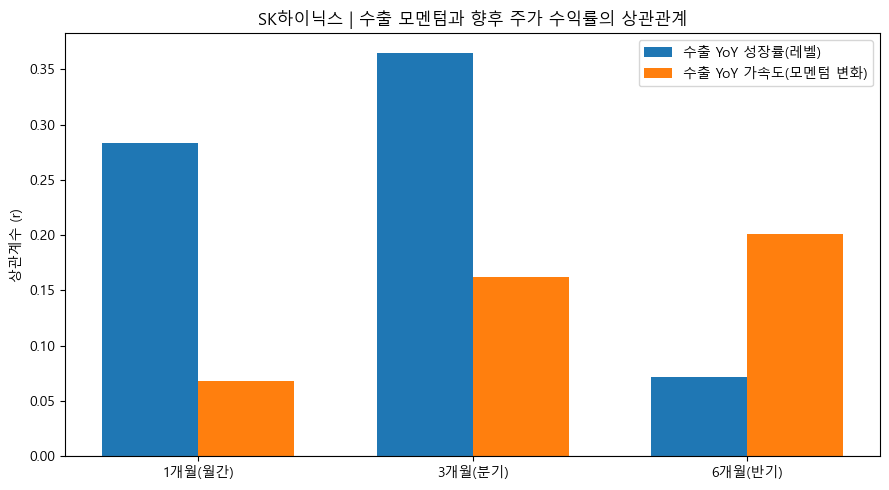

In [6]:
_ensure_package("scipy")
from scipy import stats as _stats

def add_forward_returns(df: pd.DataFrame, price_col: str = "close", horizons: dict = HORIZONS) -> pd.DataFrame:
    """각 시점 t 기준, 향후 h개월 누적 수익률(%)을 계산해 컬럼으로 추가."""
    out = df.copy()
    for h in horizons:
        out[f"fwd_return_{h}m(%)"] = (out[price_col].shift(-h) / out[price_col] - 1) * 100
    return out

combined_df = add_forward_returns(combined_df, horizons=HORIZONS)

EXPLAIN_VARS = {
    "export_yoy(%)": "수출 YoY 성장률(레벨)",
    "export_yoy_accel(%p)": "수출 YoY 가속도(모멘텀 변화)",
}

results = []
for xcol, xlabel in EXPLAIN_VARS.items():
    for h, hlabel in HORIZONS.items():
        ycol = f"fwd_return_{h}m(%)"
        sub = combined_df[[xcol, ycol]].dropna()
        if len(sub) < 10:
            print(f"[건너뜀] {xlabel} → {hlabel}: 표본 수 부족 (n={len(sub)})")
            continue
        slope, intercept, r, p, stderr = _stats.linregress(sub[xcol], sub[ycol])
        results.append({
            "설명변수": xlabel, "예측기간": hlabel, "n": len(sub),
            "상관계수(r)": round(r, 4), "R^2": round(r**2, 4),
            "기울기(slope)": round(slope, 4), "p-value": round(p, 4),
        })

reg_summary = pd.DataFrame(results)
print("\n[리드-래그 분석 요약] 수출 모멘텀 → 향후 주가 수익률")
display(reg_summary)

# ---- 막대차트: 예측기간별 상관계수 비교 ----
fig, ax = plt.subplots(figsize=(9, 5))
width = 0.35
x = np.arange(len(HORIZONS))
for i, (xcol, xlabel) in enumerate(EXPLAIN_VARS.items()):
    vals = []
    for h, hlabel in HORIZONS.items():
        row = reg_summary[(reg_summary["설명변수"] == xlabel) & (reg_summary["예측기간"] == hlabel)]
        vals.append(row["상관계수(r)"].values[0] if len(row) else np.nan)
    ax.bar(x + i * width, vals, width, label=xlabel)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(list(HORIZONS.values()))
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_ylabel("상관계수 (r)")
ax.set_title(f"{TICKER_NAME or TICKER} | 수출 모멘텀과 향후 주가 수익률의 상관관계")
ax.legend()
plt.tight_layout()
plt.show()


## ⑦ 산점도 + 회귀선 (전체 조합)

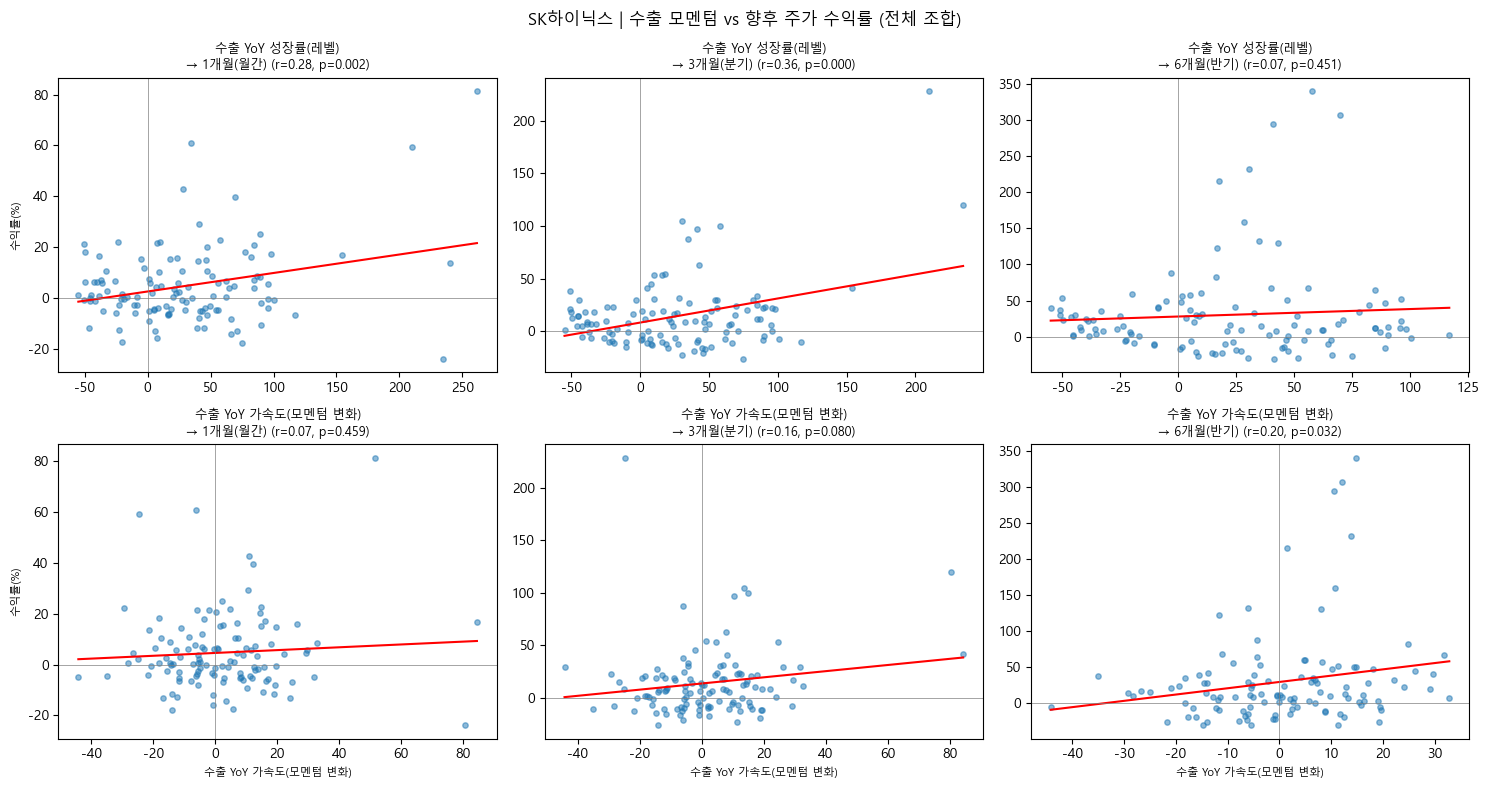

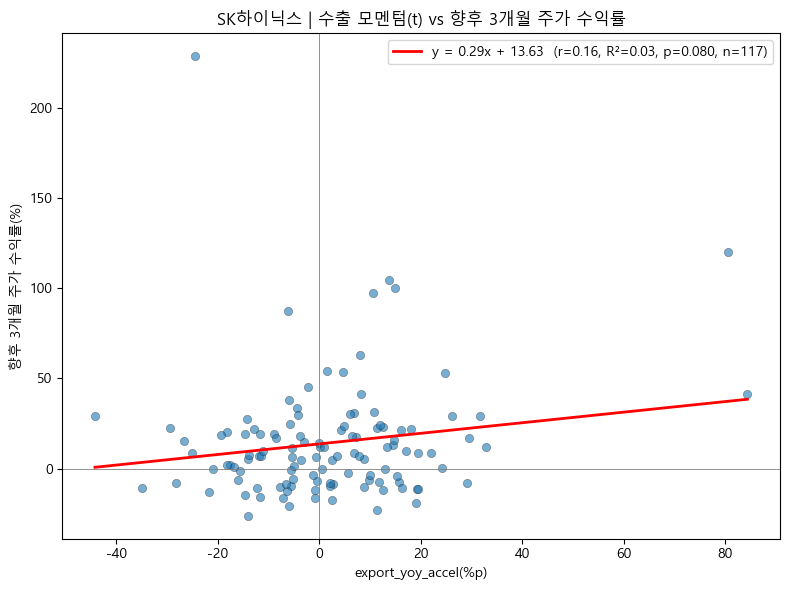

In [7]:
fig, axes = plt.subplots(len(EXPLAIN_VARS), len(HORIZONS), figsize=(15, 8))
if len(EXPLAIN_VARS) == 1:
    axes = axes.reshape(1, -1)

for i, (xcol, xlabel) in enumerate(EXPLAIN_VARS.items()):
    for j, (h, hlabel) in enumerate(HORIZONS.items()):
        ax = axes[i, j]
        ycol = f"fwd_return_{h}m(%)"
        sub = combined_df[[xcol, ycol]].dropna()
        if len(sub) < 5:
            ax.set_visible(False)
            continue
        slope, intercept, r, p, stderr = _stats.linregress(sub[xcol], sub[ycol])
        ax.scatter(sub[xcol], sub[ycol], alpha=0.5, s=15)
        xs = np.linspace(sub[xcol].min(), sub[xcol].max(), 50)
        ax.plot(xs, intercept + slope * xs, color="red", linewidth=1.5)
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.axvline(0, color="gray", linewidth=0.5)
        ax.set_title(f"{xlabel}\n→ {hlabel} (r={r:.2f}, p={p:.3f})", fontsize=9)
        if i == len(EXPLAIN_VARS) - 1:
            ax.set_xlabel(xlabel, fontsize=8)
        if j == 0:
            ax.set_ylabel("수익률(%)", fontsize=8)

plt.suptitle(f"{TICKER_NAME or TICKER} | 수출 모멘텀 vs 향후 주가 수익률 (전체 조합)")
plt.tight_layout()
plt.show()

# ---- 대표 산점도(SCATTER_XVAR, SCATTER_H) 확대 버전 ----
ycol = f"fwd_return_{SCATTER_H}m(%)"
sub = combined_df[[SCATTER_XVAR, ycol]].dropna()
if len(sub) >= 5:
    slope, intercept, r, p, stderr = _stats.linregress(sub[SCATTER_XVAR], sub[ycol])
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(sub[SCATTER_XVAR], sub[ycol], alpha=0.6, edgecolor="k", linewidth=0.3)
    xs = np.linspace(sub[SCATTER_XVAR].min(), sub[SCATTER_XVAR].max(), 50)
    ax.plot(xs, intercept + slope * xs, color="red", linewidth=2,
            label=f"y = {slope:.2f}x + {intercept:.2f}  (r={r:.2f}, R²={r**2:.2f}, p={p:.3f}, n={len(sub)})")
    ax.axhline(0, color="gray", linewidth=0.6)
    ax.axvline(0, color="gray", linewidth=0.6)
    ax.set_xlabel(SCATTER_XVAR)
    ax.set_ylabel(f"향후 {SCATTER_H}개월 주가 수익률(%)")
    ax.set_title(f"{TICKER_NAME or TICKER} | 수출 모멘텀(t) vs 향후 {SCATTER_H}개월 주가 수익률")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"[건너뜀] 대표 산점도: 표본 수 부족 (n={len(sub)})")


## ⑧ 시계열 동행성 시각화 (이중축)

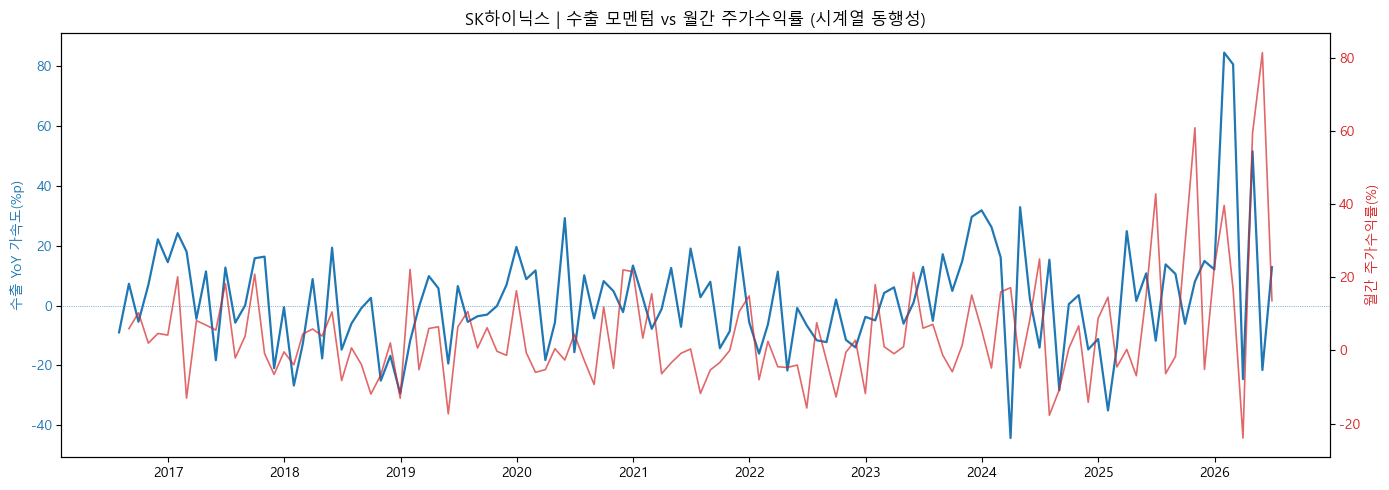


[참고] r>0 이면 수출 모멘텀이 강해질 때 향후 주가 수익률도 함께/뒤이어 상승하는 경향,
       r<0 이면 반대 방향(선반영 후 되돌림 등)일 가능성을 시사합니다.
       p-value가 0.05보다 크면 통계적으로 유의하다고 보기 어렵습니다 (표본 수 n도 함께 확인하세요).


In [8]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(combined_df.index, combined_df["export_yoy_accel(%p)"], color="#1f77b4", linewidth=1.6,
         label="수출 YoY 가속도(%p)")
ax1.axhline(0, color="#1f77b4", linewidth=0.5, linestyle=":")
ax1.set_ylabel("수출 YoY 가속도(%p)", color="#1f77b4")
ax1.tick_params(axis='y', labelcolor="#1f77b4")

ax2 = ax1.twinx()
ax2.plot(combined_df.index, combined_df["monthly_return(%)"], color="#d62728", alpha=0.7, linewidth=1.2,
         label="월간 주가수익률(%)")
ax2.set_ylabel("월간 주가수익률(%)", color="#d62728")
ax2.tick_params(axis='y', labelcolor="#d62728")

plt.title(f"{TICKER_NAME or TICKER} | 수출 모멘텀 vs 월간 주가수익률 (시계열 동행성)")
fig.tight_layout()
plt.show()

print("\n[참고] r>0 이면 수출 모멘텀이 강해질 때 향후 주가 수익률도 함께/뒤이어 상승하는 경향,")
print("       r<0 이면 반대 방향(선반영 후 되돌림 등)일 가능성을 시사합니다.")
print("       p-value가 0.05보다 크면 통계적으로 유의하다고 보기 어렵습니다 (표본 수 n도 함께 확인하세요).")


## ⑨ 시장 지수(코스피/S&P500) 통제 — 수출 모멘텀의 "순수 효과"만 분리

앞의 상관관계는 "수출이 좋을 때 반도체 업황 전체가 좋아서 시장 전체가 같이 오른 효과"가
섞여 있을 수 있습니다. 여기서는 같은 기간의 **시장 지수 수익률을 통제(잔차화)**한 뒤,
그래도 남는 "수출 모멘텀 고유의 관계"(순수 상관계수)를 따로 추출합니다.

방법: x(수출변수)와 y(향후 주가수익률) 각각을 시장지수 수익률에 회귀시켜 잔차를 구하고,
그 **잔차끼리의 상관계수(partial correlation)**를 계산합니다. 시장 공통 요인이 제거된 뒤에도
관계가 남아 있다면, 그건 시장 전체 흐름이 아니라 수출 모멘텀 자체의 정보라고 볼 수 있습니다.


시장 지수: KOSPI (^KS11)  |  통합 데이터프레임 shape: (120, 14)


,export_value,export_yoy(%),export_yoy_accel(%p),month,close,monthly_return(%),fwd_return_1m(%),fwd_return_3m(%),fwd_return_6m(%),mkt_close,mkt_monthly_return(%),mkt_fwd_return_1m(%),mkt_fwd_return_3m(%),mkt_fwd_return_6m(%)
date,,,,,,,,,,,,,,
2025-09-30,9.339170e+09,34.84,-6.09,2025-09,347500,29.18,60.86,87.34,132.23,3424.60,7.49,19.94,23.06,47.53
2025-10-31,8.886150e+09,42.85,8.01,2025-10,559000,60.86,-5.19,62.61,130.05,4107.50,19.94,-4.40,27.19,60.65
2025-11-30,1.016270e+10,57.72,14.87,2025-11,530000,-5.19,22.83,100.19,340.19,3926.59,-4.40,7.32,59.02,115.87
2025-12-31,1.263680e+10,69.75,12.04,2025-12,651000,22.83,39.63,23.96,307.07,4214.17,7.32,23.97,19.89,101.14
2026-01-31,1.211280e+10,154.14,84.39,2026-01,909000,39.63,16.72,41.47,NaN,5224.36,23.97,19.52,26.31,30.55
2026-02-28,1.581400e+10,234.62,80.48,2026-02,1061000,16.72,-23.94,119.89,NaN,6244.13,19.52,-19.08,35.75,NaN
2026-03-31,2.075750e+10,210.08,-24.54,2026-03,807000,-23.94,59.36,228.38,NaN,5052.46,-19.08,30.61,67.77,NaN
2026-04-30,2.082910e+10,261.55,51.47,2026-04,1286000,59.36,81.42,NaN,NaN,6598.87,30.61,28.45,3.36,NaN
2026-05-31,2.495060e+10,240.05,-21.50,2026-05,2333000,81.42,13.59,NaN,NaN,8476.15,28.45,0.00,NaN,NaN



[KOSPI 통제 전/후 비교]


,설명변수,예측기간,n,원래 r(통제 전),p(통제 전),순수 r(KOSPI 통제 후),p(통제 후)
0,수출 YoY 성장률(레벨),1개월(월간),119,0.2835,0.0018,0.1964,0.0323
1,수출 YoY 성장률(레벨),3개월(분기),117,0.3643,0.0001,0.2294,0.0129
2,수출 YoY 성장률(레벨),6개월(반기),114,0.0713,0.4508,0.1101,0.2436
3,수출 YoY 가속도(모멘텀 변화),1개월(월간),119,0.0685,0.4589,0.0195,0.8333
4,수출 YoY 가속도(모멘텀 변화),3개월(분기),117,0.1624,0.0802,-0.0140,0.8807
5,수출 YoY 가속도(모멘텀 변화),6개월(반기),114,0.2008,0.0321,0.0742,0.4328


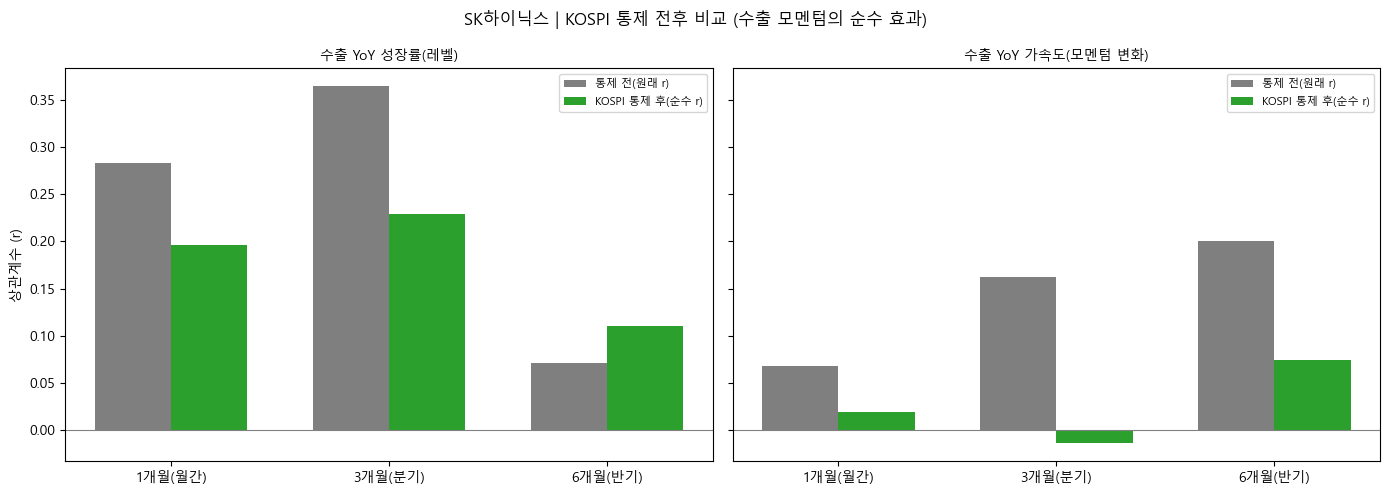


[해석] 통제 후에도 r이 크게 줄지 않고 p-value가 여전히 낮다면, 이건 시장 전체 흐름이 아니라
       수출 모멘텀 자체가 담고 있는 고유한 정보일 가능성이 높다는 뜻입니다.
       반대로 통제 후 r이 0에 가까워지면, 앞서의 관계는 상당 부분 '업황이 좋을 때 시장 전체가
       같이 오른 효과'였을 가능성이 큽니다.


In [9]:
def get_market_index_monthly_df(ticker: str, years: int = 10) -> pd.DataFrame:
    """
    시장 지수는 yfinance로 통일해서 가져옵니다.
    (FinanceDataReader의 KRX 지수 API가 세션 문제로 종종 'LOGOUT' 에러를 내는 것을 피하기 위함 —
     yfinance는 KOSPI(^KS11), S&P500(^GSPC) 등 주요 지수를 안정적으로 제공합니다.)
    """
    yf = _ensure_package("yfinance")
    end = pd.Timestamp.today()
    start = end - pd.DateOffset(years=years)
    raw = yf.download(ticker, start=start.strftime("%Y-%m-%d"), end=end.strftime("%Y-%m-%d"),
                       progress=False, auto_adjust=True)
    if raw.empty:
        raise ValueError(f"yfinance에서 {ticker} 지수 데이터를 가져오지 못했습니다.")
    close = raw["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close.index = pd.to_datetime(close.index)
    monthly_close = close.resample("M").last().dropna()
    monthly_return = monthly_close.pct_change() * 100
    df = pd.DataFrame({"close": monthly_close, "monthly_return(%)": monthly_return})
    df["month"] = df.index.to_period("M")
    return df


MARKET_INDEX_TICKER = "^KS11" if MARKET.upper() == "KR" else "^GSPC"
MARKET_INDEX_NAME   = "KOSPI" if MARKET.upper() == "KR" else "S&P 500"

market_df = get_market_index_monthly_df(MARKET_INDEX_TICKER, YEARS_STOCK)
market_df = add_forward_returns(market_df, price_col="close", horizons=HORIZONS)
market_df = market_df.rename(columns={
    "close": "mkt_close",
    "monthly_return(%)": "mkt_monthly_return(%)",
    **{f"fwd_return_{h}m(%)": f"mkt_fwd_return_{h}m(%)" for h in HORIZONS},
})

_mkt_cols = ["month", "mkt_close", "mkt_monthly_return(%)"] + [f"mkt_fwd_return_{h}m(%)" for h in HORIZONS]
combined_df = pd.merge(
    combined_df.reset_index(),
    market_df.reset_index()[_mkt_cols],
    on="month", how="left"
).set_index("date").sort_index()

print(f"시장 지수: {MARKET_INDEX_NAME} ({MARKET_INDEX_TICKER})  |  통합 데이터프레임 shape: {combined_df.shape}")
display(combined_df.tail(10).round(2))


def partial_corr(df: pd.DataFrame, xcol: str, ycol: str, control_col: str) -> dict:
    """control_col(시장지수 수익률)의 영향을 제거한 뒤, x와 y 잔차끼리의 순수 상관계수를 계산."""
    sub = df[[xcol, ycol, control_col]].dropna()
    n = len(sub)
    if n < 15:
        return {"n": n, "r": np.nan, "p": np.nan}
    sx, ix, *_ = _stats.linregress(sub[control_col], sub[xcol])
    resid_x = sub[xcol] - (ix + sx * sub[control_col])
    sy, iy, *_ = _stats.linregress(sub[control_col], sub[ycol])
    resid_y = sub[ycol] - (iy + sy * sub[control_col])
    r, p = _stats.pearsonr(resid_x, resid_y)
    return {"n": n, "r": r, "p": p}


controlled_results = []
for xcol, xlabel in EXPLAIN_VARS.items():
    for h, hlabel in HORIZONS.items():
        ycol = f"fwd_return_{h}m(%)"
        ctrl_col = f"mkt_fwd_return_{h}m(%)"
        raw_row = reg_summary[(reg_summary["설명변수"] == xlabel) & (reg_summary["예측기간"] == hlabel)]
        raw_r = raw_row["상관계수(r)"].values[0] if len(raw_row) else np.nan
        raw_p = raw_row["p-value"].values[0] if len(raw_row) else np.nan
        pc = partial_corr(combined_df, xcol, ycol, ctrl_col)
        controlled_results.append({
            "설명변수": xlabel, "예측기간": hlabel, "n": pc["n"],
            "원래 r(통제 전)": raw_r, "p(통제 전)": raw_p,
            f"순수 r({MARKET_INDEX_NAME} 통제 후)": pc["r"], "p(통제 후)": pc["p"],
        })

controlled_df = pd.DataFrame(controlled_results).round(4)
print(f"\n[{MARKET_INDEX_NAME} 통제 전/후 비교]")
display(controlled_df)

# ---- 막대차트: 통제 전(원래 r) vs 통제 후(순수 r) ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
width = 0.35
x = np.arange(len(HORIZONS))
ctrl_col_name = f"순수 r({MARKET_INDEX_NAME} 통제 후)"

for ax, (xcol, xlabel) in zip(axes, EXPLAIN_VARS.items()):
    sub = controlled_df[controlled_df["설명변수"] == xlabel]
    ax.bar(x - width / 2, sub["원래 r(통제 전)"], width, label="통제 전(원래 r)", color="#7f7f7f")
    ax.bar(x + width / 2, sub[ctrl_col_name], width, label=f"{MARKET_INDEX_NAME} 통제 후(순수 r)", color="#2ca02c")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(list(HORIZONS.values()))
    ax.set_title(xlabel, fontsize=10)
    ax.legend(fontsize=8)

axes[0].set_ylabel("상관계수 (r)")
plt.suptitle(f"{TICKER_NAME or TICKER} | {MARKET_INDEX_NAME} 통제 전후 비교 (수출 모멘텀의 순수 효과)")
plt.tight_layout()
plt.show()

print("\n[해석] 통제 후에도 r이 크게 줄지 않고 p-value가 여전히 낮다면, 이건 시장 전체 흐름이 아니라")
print("       수출 모멘텀 자체가 담고 있는 고유한 정보일 가능성이 높다는 뜻입니다.")
print("       반대로 통제 후 r이 0에 가까워지면, 앞서의 관계는 상당 부분 '업황이 좋을 때 시장 전체가")
print("       같이 오른 효과'였을 가능성이 큽니다.")


## ⑩ 수출 모멘텀(레벨) + 월간 주가 흐름 시각화

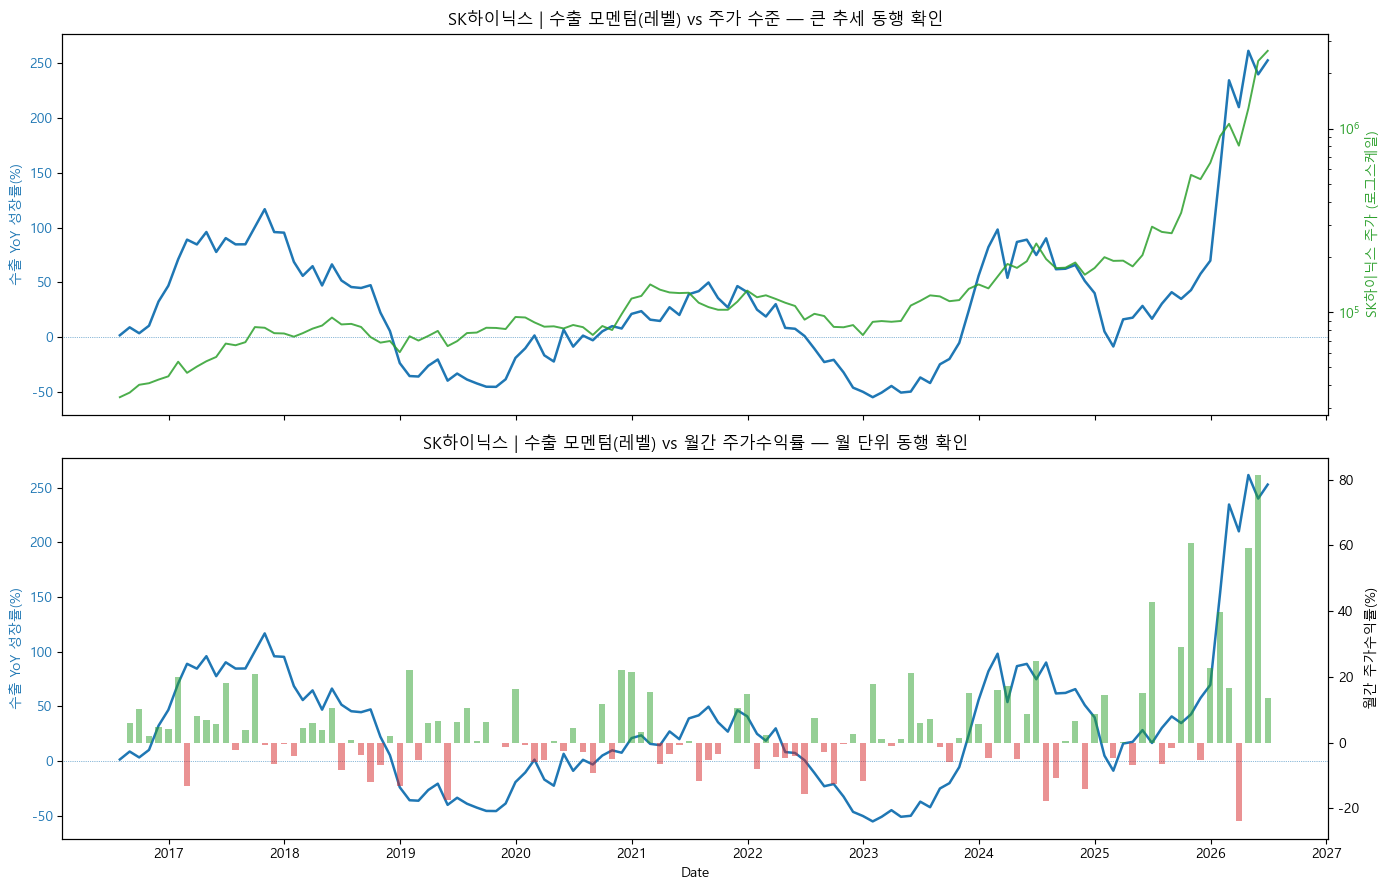

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ---- 위: 수출 YoY 레벨(좌축) vs 주가 수준(우축, 로그스케일) — 큰 추세 동행 확인 ----
ax1.plot(combined_df.index, combined_df["export_yoy(%)"], color="#1f77b4", linewidth=1.8,
         label="수출 YoY 성장률(%)")
ax1.axhline(0, color="#1f77b4", linewidth=0.5, linestyle=":")
ax1.set_ylabel("수출 YoY 성장률(%)", color="#1f77b4")
ax1.tick_params(axis='y', labelcolor="#1f77b4")

ax1b = ax1.twinx()
ax1b.plot(combined_df.index, combined_df["close"], color="#2ca02c", linewidth=1.4, alpha=0.85,
          label=f"{TICKER_NAME or TICKER} 주가")
ax1b.set_yscale("log")
ax1b.set_ylabel(f"{TICKER_NAME or TICKER} 주가 (로그스케일)", color="#2ca02c")
ax1b.tick_params(axis='y', labelcolor="#2ca02c")
ax1.set_title(f"{TICKER_NAME or TICKER} | 수출 모멘텀(레벨) vs 주가 수준 — 큰 추세 동행 확인")

# ---- 아래: 수출 YoY 레벨(좌축) vs 월간 주가수익률(우축, 막대) — 월 단위 동행 확인 ----
ax2.plot(combined_df.index, combined_df["export_yoy(%)"], color="#1f77b4", linewidth=1.8,
         label="수출 YoY 성장률(%)")
ax2.axhline(0, color="#1f77b4", linewidth=0.5, linestyle=":")
ax2.set_ylabel("수출 YoY 성장률(%)", color="#1f77b4")
ax2.tick_params(axis='y', labelcolor="#1f77b4")

ax2b = ax2.twinx()
bar_colors = ["#2ca02c" if v >= 0 else "#d62728" for v in combined_df["monthly_return(%)"].fillna(0)]
ax2b.bar(combined_df.index, combined_df["monthly_return(%)"], color=bar_colors, alpha=0.5, width=20,
         label="월간 주가수익률(%)")
ax2b.set_ylabel("월간 주가수익률(%)")
ax2.set_title(f"{TICKER_NAME or TICKER} | 수출 모멘텀(레벨) vs 월간 주가수익률 — 월 단위 동행 확인")
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()


## ⑪ 단가(가격) 모멘텀 데이터프레임: 수출금액 ÷ 수출중량

지금까지는 "수출금액"의 YoY/가속도를 봤는데, 금액 증가가 **물량** 때문인지 **단가(가격)** 때문인지는
구분되지 않았습니다. 여기서는 `HSCODE_LIST`의 수출금액 합계 ÷ 수출중량 합계로 **평균 단가**를 구하고,
그 단가의 YoY 성장률(%)과 YoY의 월별 변화(**d_YoY**, %p = 가속도)를 계산합니다.

- 무게(중량) indicator 이름은 DB마다 다를 수 있어 자동 탐지합니다. 후보가 여러 개면
  `get_price_momentum_df(..., weight_indicator_override="실제이름")`으로 직접 지정하세요.


In [11]:
def get_price_momentum_df(engine, db_info, hscode_list,
                           weight_indicator_override: str | None = None,
                           trade_table: str = "korea_monthly_trade_data") -> pd.DataFrame:
    """
    hscode_list의 수출금액 합계 / 수출중량 합계 = 평균 단가(unit_price)를 월별로 계산하고,
    단가의 YoY(%)와 YoY의 전월대비 변화(d_YoY, %p = 가속도)를 반환합니다.
    """
    trade_data_df = fetch_table_data(db_info, trade_table)

    weight_indicator = "expWgt"
    if weight_indicator is None:
        inds = trade_data_df["indicator"].dropna().unique().tolist()
        keywords = ["weight", "kg", "ton", "qty", "중량", "무게", "물량"]
        candidates = [i for i in inds if any(k in str(i).lower() for k in keywords)]
        print(f"[무게 indicator 후보]: {candidates}  (전체 indicator 목록: {inds})")
        if len(candidates) == 1:
            weight_indicator = candidates[0]
            print(f"[자동 감지] '{weight_indicator}' 사용")
        else:
            raise ValueError(
                f"무게 indicator를 자동으로 하나로 특정하지 못했습니다 (후보: {candidates}). "
                f"get_price_momentum_df(..., weight_indicator_override='실제이름')으로 직접 지정하세요."
            )

    value_pv = pivot_dataframe(trade_data_df, index_col='date', column_col='root_hs_code',
                                indicator_col='indicator', value_col='value', indicator_value='expDlr')
    weight_pv = pivot_dataframe(trade_data_df, index_col='date', column_col='root_hs_code',
                                 indicator_col='indicator', value_col='value', indicator_value=weight_indicator)

    for pv in (value_pv, weight_pv):
        pv.index = pd.to_datetime(pv.index)
        pv.sort_index(inplace=True)
        pv.columns = pv.columns.astype(str)

    present_v = set(h for h in hscode_list if h in value_pv.columns)
    present_w = set(h for h in hscode_list if h in weight_pv.columns)
    present = [h for h in hscode_list if h in present_v and h in present_w]
    missing = [h for h in hscode_list if h not in present]
    if missing:
        print(f"[경고] 다음 HS 코드는 금액 또는 중량 데이터가 없어 단가 계산에서 제외됩니다: {missing}")
    if not present:
        raise ValueError("단가를 계산할 수 있는 유효한 HS 코드가 없습니다.")

    total_value = value_pv[present].sum(axis=1, skipna=True)
    total_weight = weight_pv[present].sum(axis=1, skipna=True)

    df = pd.DataFrame({"export_value": total_value, "export_weight": total_weight}).dropna()
    df = df[df["export_weight"] > 0]
    df["unit_price"] = df["export_value"] / df["export_weight"]
    df["price_yoy(%)"] = df["unit_price"].pct_change(12) * 100
    df["price_yoy_accel(%p)"] = df["price_yoy(%)"].diff(1)   # d_YoY (가속도)
    df["month"] = df.index.to_period("M")
    return df


price_df = get_price_momentum_df(engine, db_info, HSCODE_LIST)
print(f"\n단가 모멘텀 데이터프레임 shape: {price_df.shape}  "
      f"(기간: {price_df.index.min().date()} ~ {price_df.index.max().date()})")
display(price_df.tail(10).round(4))

# ---- 통합 데이터프레임에 단가 변수 결합 ----
combined_df = pd.merge(
    combined_df.reset_index(),
    price_df.reset_index()[["month", "unit_price", "price_yoy(%)", "price_yoy_accel(%p)"]],
    on="month", how="left"
).set_index("date").sort_index()
print(f"\n통합 데이터프레임(단가 포함) shape: {combined_df.shape}")


✅ 'korea_monthly_trade_data' 테이블에서 1428902건의 데이터를 가져왔습니다.

단가 모멘텀 데이터프레임 shape: (234, 6)  (기간: 2007-01-31 ~ 2026-06-30)


,export_value,export_weight,unit_price,price_yoy(%),price_yoy_accel(%p),month
date,,,,,,
2025-09-30,9.339170e+09,369663.0,25264.0107,6.1261,-2.5473,2025-09
2025-10-31,8.886150e+09,310324.0,28635.0717,-2.1806,-8.3067,2025-10
2025-11-30,1.016270e+10,306192.0,33190.6124,32.8115,34.9921,2025-11
2025-12-31,1.263680e+10,359385.0,35162.2911,34.9735,2.1621,2025-12
2026-01-31,1.211280e+10,302646.0,40022.9972,92.4831,57.5096,2026-01
2026-02-28,1.581400e+10,287941.0,54920.9734,194.8408,102.3577,2026-02
2026-03-31,2.075750e+10,375408.0,55293.1744,175.5664,-19.2744,2026-03
2026-04-30,2.082910e+10,319350.0,65223.4226,220.2023,44.6359,2026-04
2026-05-31,2.495060e+10,326953.0,76312.4975,255.0397,34.8374,2026-05



통합 데이터프레임(단가 포함) shape: (120, 17)


## ⑫ 리드-래그 분석: 단가(가격) YoY / d_YoY(가속도) → 향후 주가 수익률


[리드-래그 분석 요약] 단가(가격) 모멘텀 → 향후 주가 수익률


,설명변수,예측기간,n,상관계수(r),R^2,기울기(slope),p-value
0,단가 YoY 성장률(레벨),1개월(월간),119,0.2129,0.0453,0.0542,0.0201
1,단가 YoY 성장률(레벨),3개월(분기),117,0.2377,0.0565,0.1466,0.0099
2,단가 YoY 성장률(레벨),6개월(반기),114,-0.0432,0.0019,-0.0567,0.6480
3,단가 YoY 가속도(d_YoY),1개월(월간),119,0.0425,0.0018,0.0315,0.6462
4,단가 YoY 가속도(d_YoY),3개월(분기),117,0.1801,0.0324,0.2939,0.0520
5,단가 YoY 가속도(d_YoY),6개월(반기),114,0.1404,0.0197,0.5259,0.1362


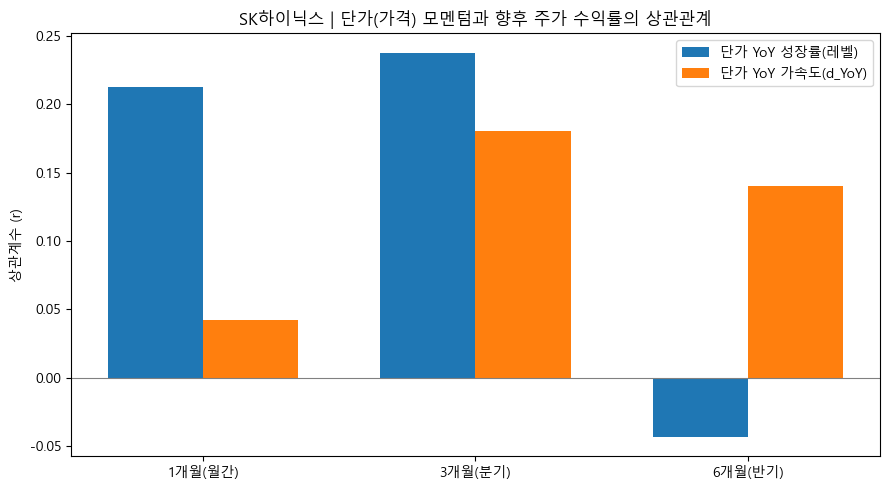

In [12]:
PRICE_EXPLAIN_VARS = {
    "price_yoy(%)": "단가 YoY 성장률(레벨)",
    "price_yoy_accel(%p)": "단가 YoY 가속도(d_YoY)",
}

price_results = []
for xcol, xlabel in PRICE_EXPLAIN_VARS.items():
    for h, hlabel in HORIZONS.items():
        ycol = f"fwd_return_{h}m(%)"
        sub = combined_df[[xcol, ycol]].dropna()
        if len(sub) < 10:
            print(f"[건너뜀] {xlabel} → {hlabel}: 표본 수 부족 (n={len(sub)})")
            continue
        slope, intercept, r, p, stderr = _stats.linregress(sub[xcol], sub[ycol])
        price_results.append({
            "설명변수": xlabel, "예측기간": hlabel, "n": len(sub),
            "상관계수(r)": round(r, 4), "R^2": round(r**2, 4),
            "기울기(slope)": round(slope, 4), "p-value": round(p, 4),
        })

price_reg_summary = pd.DataFrame(price_results)
print("\n[리드-래그 분석 요약] 단가(가격) 모멘텀 → 향후 주가 수익률")
display(price_reg_summary)

# ---- 막대차트: 예측기간별 상관계수 비교 ----
fig, ax = plt.subplots(figsize=(9, 5))
width = 0.35
x = np.arange(len(HORIZONS))
for i, (xcol, xlabel) in enumerate(PRICE_EXPLAIN_VARS.items()):
    vals = []
    for h, hlabel in HORIZONS.items():
        row = price_reg_summary[(price_reg_summary["설명변수"] == xlabel) & (price_reg_summary["예측기간"] == hlabel)]
        vals.append(row["상관계수(r)"].values[0] if len(row) else np.nan)
    ax.bar(x + i * width, vals, width, label=xlabel)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(list(HORIZONS.values()))
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_ylabel("상관계수 (r)")
ax.set_title(f"{TICKER_NAME or TICKER} | 단가(가격) 모멘텀과 향후 주가 수익률의 상관관계")
ax.legend()
plt.tight_layout()
plt.show()


## ⑬ 산점도 + 회귀선 (단가 변수, 전체 조합)

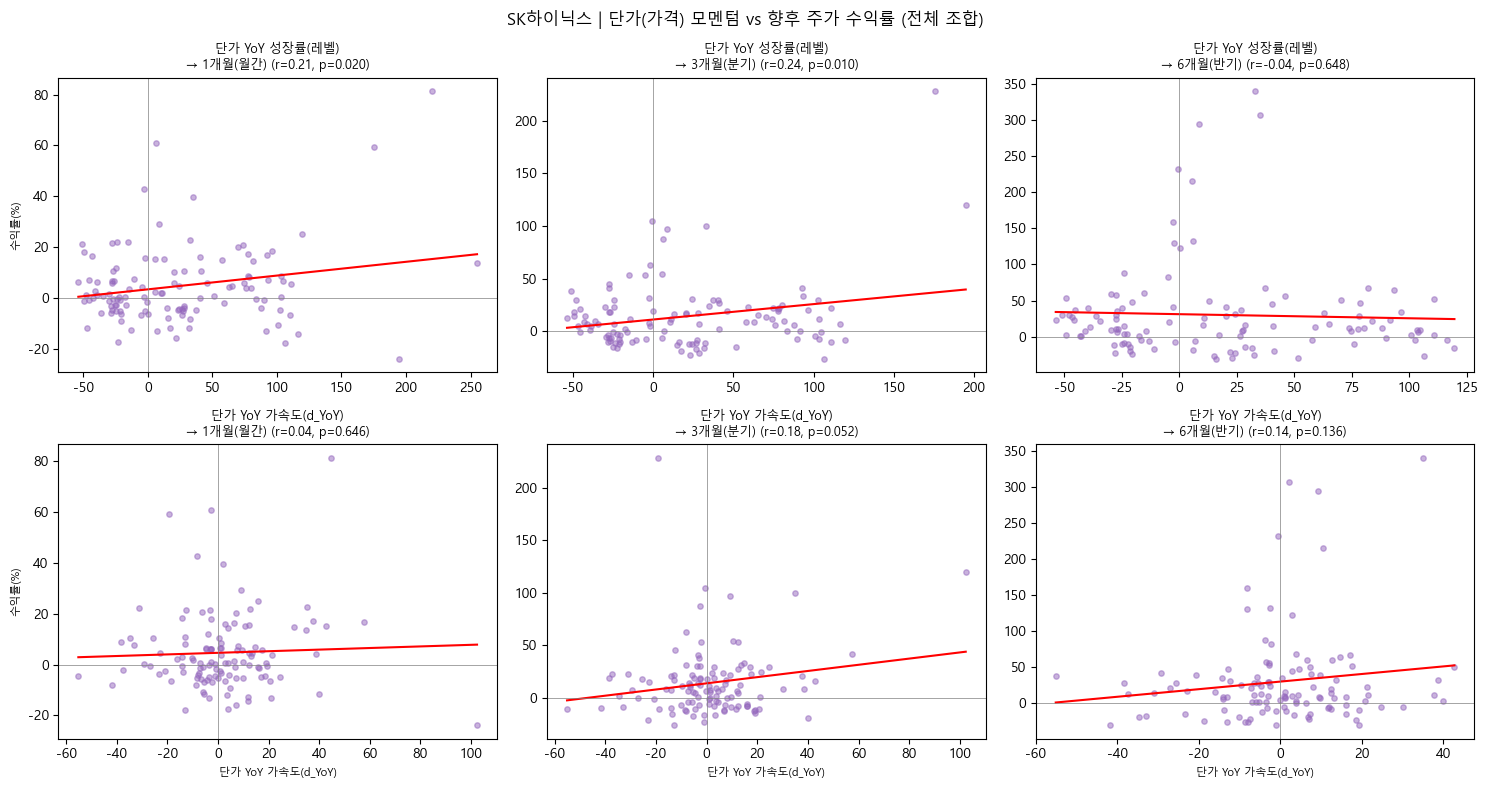

In [13]:
fig, axes = plt.subplots(len(PRICE_EXPLAIN_VARS), len(HORIZONS), figsize=(15, 8))
if len(PRICE_EXPLAIN_VARS) == 1:
    axes = axes.reshape(1, -1)

for i, (xcol, xlabel) in enumerate(PRICE_EXPLAIN_VARS.items()):
    for j, (h, hlabel) in enumerate(HORIZONS.items()):
        ax = axes[i, j]
        ycol = f"fwd_return_{h}m(%)"
        sub = combined_df[[xcol, ycol]].dropna()
        if len(sub) < 5:
            ax.set_visible(False)
            continue
        slope, intercept, r, p, stderr = _stats.linregress(sub[xcol], sub[ycol])
        ax.scatter(sub[xcol], sub[ycol], alpha=0.5, s=15, color="#9467bd")
        xs = np.linspace(sub[xcol].min(), sub[xcol].max(), 50)
        ax.plot(xs, intercept + slope * xs, color="red", linewidth=1.5)
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.axvline(0, color="gray", linewidth=0.5)
        ax.set_title(f"{xlabel}\n→ {hlabel} (r={r:.2f}, p={p:.3f})", fontsize=9)
        if i == len(PRICE_EXPLAIN_VARS) - 1:
            ax.set_xlabel(xlabel, fontsize=8)
        if j == 0:
            ax.set_ylabel("수익률(%)", fontsize=8)

plt.suptitle(f"{TICKER_NAME or TICKER} | 단가(가격) 모멘텀 vs 향후 주가 수익률 (전체 조합)")
plt.tight_layout()
plt.show()


## ⑭ 시장 지수 통제 — 단가(가격) 모멘텀의 "순수 효과" 분리

⑨번에서 만든 `partial_corr()`와 시장지수 향후수익률(`mkt_fwd_return_{h}m(%)`)을 그대로 재사용합니다.



[단가 모멘텀 | KOSPI 통제 전/후 비교]


,설명변수,예측기간,n,원래 r(통제 전),p(통제 전),순수 r(KOSPI 통제 후),p(통제 후)
0,단가 YoY 성장률(레벨),1개월(월간),119,0.2129,0.0201,0.1959,0.0328
1,단가 YoY 성장률(레벨),3개월(분기),117,0.2377,0.0099,0.2398,0.0092
2,단가 YoY 성장률(레벨),6개월(반기),114,-0.0432,0.6480,0.1286,0.1728
3,단가 YoY 가속도(d_YoY),1개월(월간),119,0.0425,0.6462,0.0279,0.7636
4,단가 YoY 가속도(d_YoY),3개월(분기),117,0.1801,0.0520,0.0022,0.9812
5,단가 YoY 가속도(d_YoY),6개월(반기),114,0.1404,0.1362,0.0836,0.3765


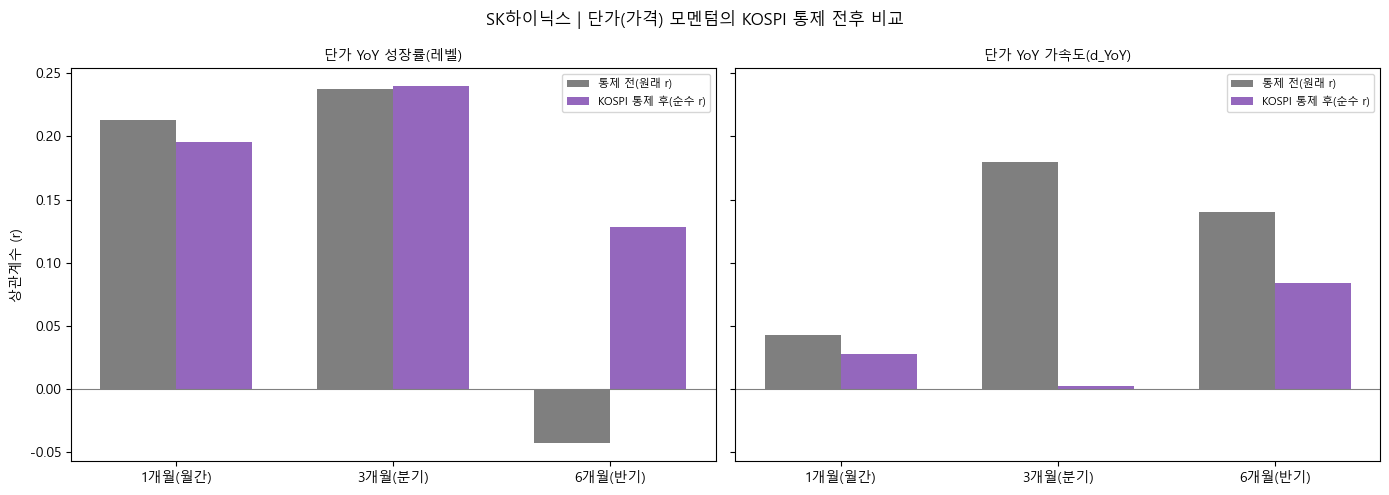

In [14]:
price_controlled_results = []
for xcol, xlabel in PRICE_EXPLAIN_VARS.items():
    for h, hlabel in HORIZONS.items():
        ycol = f"fwd_return_{h}m(%)"
        ctrl_col = f"mkt_fwd_return_{h}m(%)"
        raw_row = price_reg_summary[(price_reg_summary["설명변수"] == xlabel) & (price_reg_summary["예측기간"] == hlabel)]
        raw_r = raw_row["상관계수(r)"].values[0] if len(raw_row) else np.nan
        raw_p = raw_row["p-value"].values[0] if len(raw_row) else np.nan
        pc = partial_corr(combined_df, xcol, ycol, ctrl_col)
        price_controlled_results.append({
            "설명변수": xlabel, "예측기간": hlabel, "n": pc["n"],
            "원래 r(통제 전)": raw_r, "p(통제 전)": raw_p,
            f"순수 r({MARKET_INDEX_NAME} 통제 후)": pc["r"], "p(통제 후)": pc["p"],
        })

price_controlled_df = pd.DataFrame(price_controlled_results).round(4)
print(f"\n[단가 모멘텀 | {MARKET_INDEX_NAME} 통제 전/후 비교]")
display(price_controlled_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
width = 0.35
x = np.arange(len(HORIZONS))
ctrl_col_name = f"순수 r({MARKET_INDEX_NAME} 통제 후)"

for ax, (xcol, xlabel) in zip(axes, PRICE_EXPLAIN_VARS.items()):
    sub = price_controlled_df[price_controlled_df["설명변수"] == xlabel]
    ax.bar(x - width / 2, sub["원래 r(통제 전)"], width, label="통제 전(원래 r)", color="#7f7f7f")
    ax.bar(x + width / 2, sub[ctrl_col_name], width, label=f"{MARKET_INDEX_NAME} 통제 후(순수 r)", color="#9467bd")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(list(HORIZONS.values()))
    ax.set_title(xlabel, fontsize=10)
    ax.legend(fontsize=8)

axes[0].set_ylabel("상관계수 (r)")
plt.suptitle(f"{TICKER_NAME or TICKER} | 단가(가격) 모멘텀의 {MARKET_INDEX_NAME} 통제 전후 비교")
plt.tight_layout()
plt.show()


## ⑮ 단가(레벨) + 월간 주가 흐름 시계열 동행성

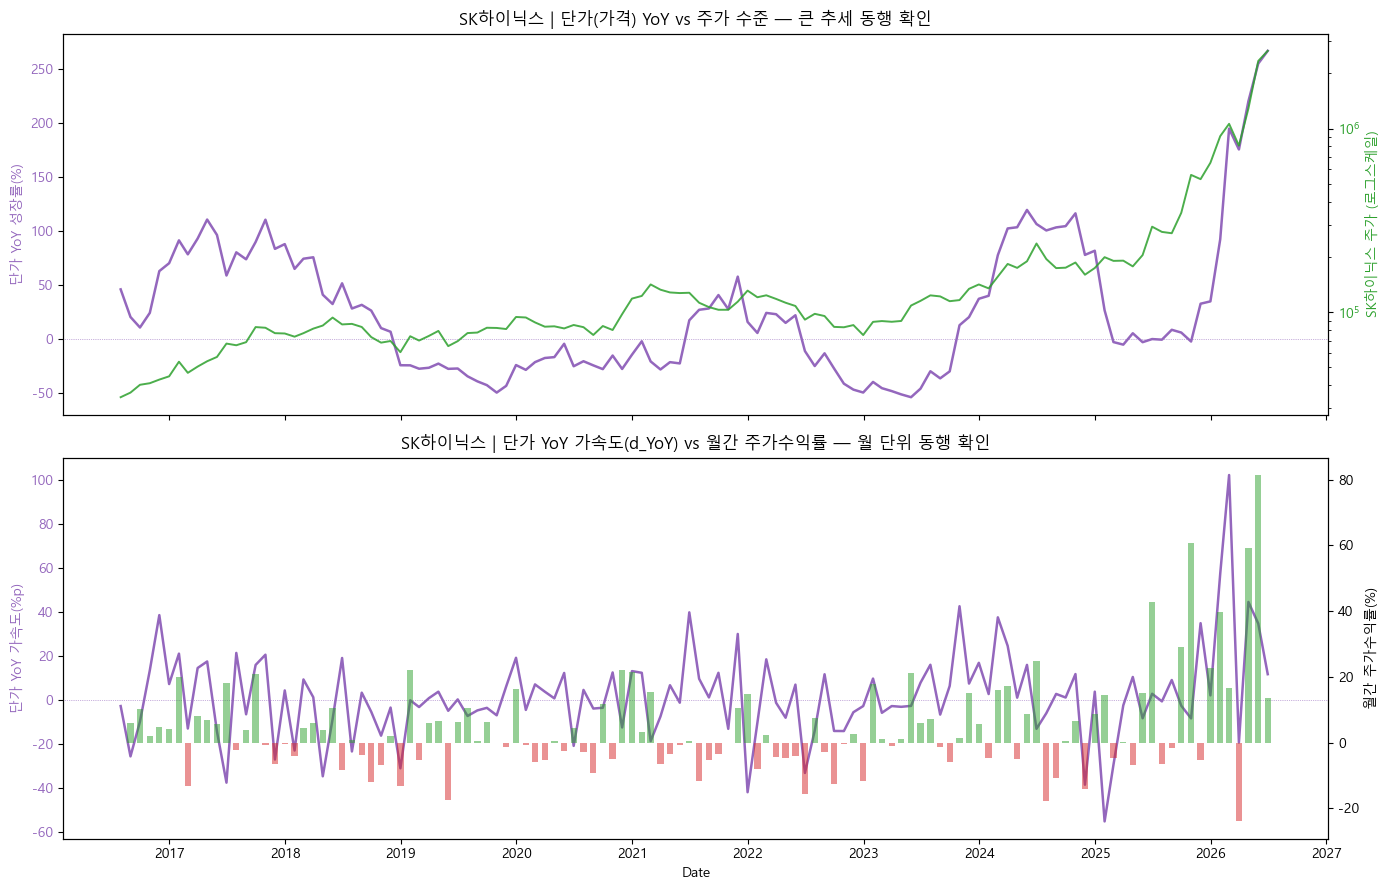


[해석] 위쪽: 단가(가격) 자체의 전년동월비 흐름과 주가 수준의 큰 추세가 같이 가는지.
       아래쪽: 단가 YoY의 '변화 속도'(d_YoY)가 월간 주가수익률과 같이 움직이는지.
       ⑥·⑨번의 수출금액 기반 결과와 비교하면, 수출 증가가 '물량 때문'인지 '가격(단가) 때문'인지
       어느 쪽이 주가와 더 강하게 연결되는 신호인지 판단하는 데 도움이 됩니다.


In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ---- 위: 단가 YoY(좌축) vs 주가 수준(우축, 로그스케일) ----
ax1.plot(combined_df.index, combined_df["price_yoy(%)"], color="#9467bd", linewidth=1.8,
         label="단가 YoY 성장률(%)")
ax1.axhline(0, color="#9467bd", linewidth=0.5, linestyle=":")
ax1.set_ylabel("단가 YoY 성장률(%)", color="#9467bd")
ax1.tick_params(axis='y', labelcolor="#9467bd")

ax1b = ax1.twinx()
ax1b.plot(combined_df.index, combined_df["close"], color="#2ca02c", linewidth=1.4, alpha=0.85,
          label=f"{TICKER_NAME or TICKER} 주가")
ax1b.set_yscale("log")
ax1b.set_ylabel(f"{TICKER_NAME or TICKER} 주가 (로그스케일)", color="#2ca02c")
ax1b.tick_params(axis='y', labelcolor="#2ca02c")
ax1.set_title(f"{TICKER_NAME or TICKER} | 단가(가격) YoY vs 주가 수준 — 큰 추세 동행 확인")

# ---- 아래: 단가 YoY 가속도(d_YoY, 좌축) vs 월간 주가수익률(우축, 막대) ----
ax2.plot(combined_df.index, combined_df["price_yoy_accel(%p)"], color="#9467bd", linewidth=1.8,
         label="단가 YoY 가속도(d_YoY, %p)")
ax2.axhline(0, color="#9467bd", linewidth=0.5, linestyle=":")
ax2.set_ylabel("단가 YoY 가속도(%p)", color="#9467bd")
ax2.tick_params(axis='y', labelcolor="#9467bd")

ax2b = ax2.twinx()
bar_colors = ["#2ca02c" if v >= 0 else "#d62728" for v in combined_df["monthly_return(%)"].fillna(0)]
ax2b.bar(combined_df.index, combined_df["monthly_return(%)"], color=bar_colors, alpha=0.5, width=20)
ax2b.set_ylabel("월간 주가수익률(%)")
ax2.set_title(f"{TICKER_NAME or TICKER} | 단가 YoY 가속도(d_YoY) vs 월간 주가수익률 — 월 단위 동행 확인")
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()

print("\n[해석] 위쪽: 단가(가격) 자체의 전년동월비 흐름과 주가 수준의 큰 추세가 같이 가는지.")
print("       아래쪽: 단가 YoY의 '변화 속도'(d_YoY)가 월간 주가수익률과 같이 움직이는지.")
print("       ⑥·⑨번의 수출금액 기반 결과와 비교하면, 수출 증가가 '물량 때문'인지 '가격(단가) 때문'인지")
print("       어느 쪽이 주가와 더 강하게 연결되는 신호인지 판단하는 데 도움이 됩니다.")


## ⑯ 전체 상관관계 한눈에 보기 — 히트맵

지금까지 따로 계산했던 표들(수출 `reg_summary`, 단가 `price_reg_summary`)을 하나로 합쳐서
**(설명변수) × (예측기간)** 상관계수를 히트맵 한 장으로 정리합니다. 블로그/영상에서 결과를
한 장으로 요약해서 보여줄 때 가장 쓰기 좋은 자료입니다.


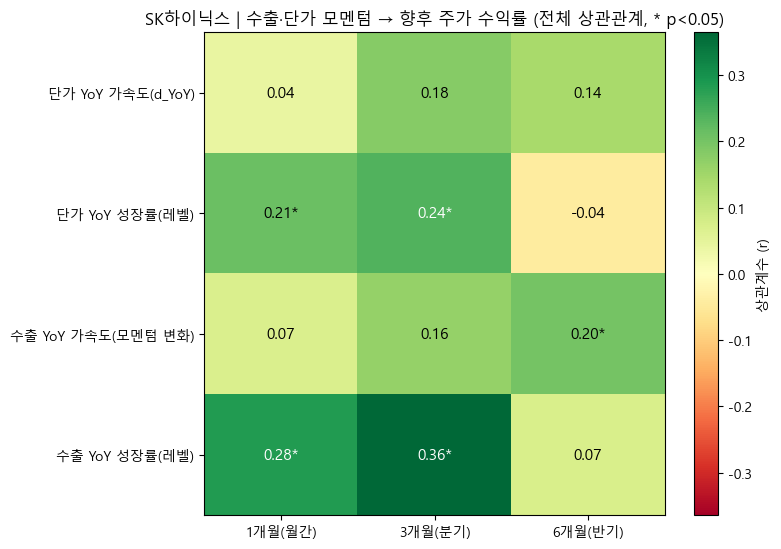


[전체 리드-래그 상관관계 요약 표]


,설명변수,예측기간,n,상관계수(r),R^2,기울기(slope),p-value
0,단가 YoY 가속도(d_YoY),1개월(월간),119,0.0425,0.0018,0.0315,0.6462
1,단가 YoY 가속도(d_YoY),3개월(분기),117,0.1801,0.0324,0.2939,0.0520
2,단가 YoY 가속도(d_YoY),6개월(반기),114,0.1404,0.0197,0.5259,0.1362
3,단가 YoY 성장률(레벨),1개월(월간),119,0.2129,0.0453,0.0542,0.0201
4,단가 YoY 성장률(레벨),3개월(분기),117,0.2377,0.0565,0.1466,0.0099
5,단가 YoY 성장률(레벨),6개월(반기),114,-0.0432,0.0019,-0.0567,0.6480
6,수출 YoY 가속도(모멘텀 변화),1개월(월간),119,0.0685,0.0047,0.0558,0.4589
7,수출 YoY 가속도(모멘텀 변화),3개월(분기),117,0.1624,0.0264,0.2932,0.0802
8,수출 YoY 가속도(모멘텀 변화),6개월(반기),114,0.2008,0.0403,0.8722,0.0321
9,수출 YoY 성장률(레벨),1개월(월간),119,0.2835,0.0804,0.0728,0.0018


In [16]:
all_reg_summary = pd.concat([reg_summary, price_reg_summary], ignore_index=True)

_horizon_order = list(HORIZONS.values())
heatmap_data = all_reg_summary.pivot(index="설명변수", columns="예측기간", values="상관계수(r)")
heatmap_data = heatmap_data[[h for h in _horizon_order if h in heatmap_data.columns]]

fig, ax = plt.subplots(figsize=(8, 0.9 * len(heatmap_data) + 2))
vmax = max(0.1, np.nanmax(np.abs(heatmap_data.values)))
im = ax.imshow(heatmap_data.values, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for i, xlabel in enumerate(heatmap_data.index):
    for j, hlabel in enumerate(heatmap_data.columns):
        val = heatmap_data.values[i, j]
        p_row = all_reg_summary[(all_reg_summary["설명변수"] == xlabel) & (all_reg_summary["예측기간"] == hlabel)]
        p_val = p_row["p-value"].values[0] if len(p_row) else np.nan
        marker = "*" if pd.notna(p_val) and p_val < 0.05 else ""
        txt_color = "black" if abs(val) < vmax * 0.6 else "white"
        ax.text(j, i, f"{val:.2f}{marker}", ha="center", va="center", color=txt_color, fontsize=11)

plt.colorbar(im, ax=ax, label="상관계수 (r)")
ax.set_title(f"{TICKER_NAME or TICKER} | 수출·단가 모멘텀 → 향후 주가 수익률 (전체 상관관계, * p<0.05)")
plt.tight_layout()
plt.show()

print("\n[전체 리드-래그 상관관계 요약 표]")
display(all_reg_summary.sort_values(["설명변수", "예측기간"]).reset_index(drop=True))


## ⑰ 변수 간 동시(contemporaneous) 상관관계 행렬

리드-래그(시차) 상관관계와는 별개로, **같은 달 기준**으로 수출 모멘텀·단가 모멘텀·주가수익률·
시장수익률이 서로 얼마나 같이 움직이는지도 확인해 둘 필요가 있습니다 (예: 단가와 수출금액이
서로 얼마나 겹치는 정보인지, 개별 종목 수익률이 시장과 얼마나 같이 가는지=베타 감).


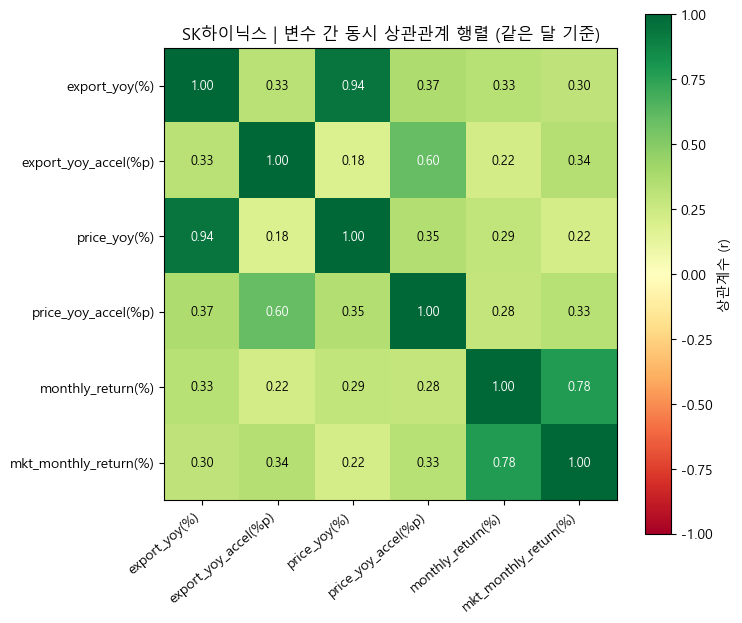


[해석 힌트]
 - export_yoy(%) vs price_yoy(%): 두 값이 얼마나 겹치는 정보인지 (많이 겹치면 물량효과가 작다는 뜻)
 - monthly_return(%) vs mkt_monthly_return(%): 이 종목이 시장과 얼마나 같이 움직이는지 (베타 감)


,export_yoy(%),export_yoy_accel(%p),price_yoy(%),price_yoy_accel(%p),monthly_return(%),mkt_monthly_return(%)
export_yoy(%),1.000,0.325,0.938,0.366,0.335,0.300
export_yoy_accel(%p),0.325,1.000,0.180,0.600,0.222,0.342
price_yoy(%),0.938,0.180,1.000,0.347,0.292,0.217
price_yoy_accel(%p),0.366,0.600,0.347,1.000,0.285,0.333
monthly_return(%),0.335,0.222,0.292,0.285,1.000,0.777
mkt_monthly_return(%),0.300,0.342,0.217,0.333,0.777,1.000


In [17]:
_corr_candidates = [
    "export_yoy(%)", "export_yoy_accel(%p)",
    "price_yoy(%)", "price_yoy_accel(%p)",
    "monthly_return(%)", "mkt_monthly_return(%)",
]
corr_cols = [c for c in _corr_candidates if c in combined_df.columns]
corr_matrix = combined_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr_matrix.values, cmap="RdYlGn", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=40, ha="right")
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="black" if abs(val) < 0.6 else "white", fontsize=9)

plt.colorbar(im, ax=ax, label="상관계수 (r)")
ax.set_title(f"{TICKER_NAME or TICKER} | 변수 간 동시 상관관계 행렬 (같은 달 기준)")
plt.tight_layout()
plt.show()

print("\n[해석 힌트]")
print(" - export_yoy(%) vs price_yoy(%): 두 값이 얼마나 겹치는 정보인지 (많이 겹치면 물량효과가 작다는 뜻)")
print(" - monthly_return(%) vs mkt_monthly_return(%): 이 종목이 시장과 얼마나 같이 움직이는지 (베타 감)")
display(corr_matrix.round(3))
